# Introduction

## Movie Review Sentiment Analysis

The goal of this project is to build a binary sentiment classifier that reads a movie review and predicts whether it expresses a positive or negative opinion.

We use the IMDB Large Movie Review Dataset, which contains 50,000 movie reviews. This project uses Natural Language Processing (NLP) to process the review text and machine learning algorithms to classify the sentiment.

## Why Movie Sentiment is Harder than Spam Classification

Movie sentiment analysis is more challenging than SMS spam classification because movie reviews are much longer and require understanding of context, tone, nuance, and opinion.

For example, sentiment analysis needs to understand negation such as "not bad", sarcasm such as "brilliant — if you enjoy torture", and mixed opinions such as "it's okay but...".

IMDB reviews also contain HTML tags such as `<br />` and `<i>`, which need to be removed during text preprocessing.

## Approach

The reviews will first be cleaned and preprocessed. The cleaned text will then be converted into numerical features using TF-IDF.

This project uses advanced TF-IDF settings, including:
- Unigrams, bigrams, and trigrams
- Sublinear TF scaling
- A larger number of features

Three machine learning algorithms will be compared:

1. Linear SVM (LinearSVC)
2. Logistic Regression
3. Multinomial Naive Bayes

The same feature sets and preprocessing will be used for a fair comparison between the algorithms.

## Negation Challenge

Negation is an important challenge in movie sentiment analysis.

For example:

- "This movie is good" → Positive
- "This movie is not good" → Negative
- "The movie is not bad" → Positive

Therefore, negation words such as "not", "never", and "no" must be handled carefully during preprocessing.

## Benchmark Context

The IMDB dataset is a widely used benchmark for sentiment analysis. The guide reports published results including 88.89% accuracy with Naive Bayes and approximately 93–94% accuracy with later classical machine-learning approaches using SVM and n-grams.

Our models will be evaluated and compared with these published benchmark results.

In [1]:
# Step 2: Imports & Setup

import numpy as np
import pandas as pd
import nltk
import random

random.seed(42)
np.random.seed(42)

print("Step 2 completed successfully.")

Step 2 completed successfully.


In [2]:
# Step 2: NLTK Stopwords Setup

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# Keep important negation words
stop_words.discard('not')
stop_words.discard('no')
stop_words.discard('never')

print("Stopwords setup completed.")
print("Important negation words kept: not, no, never")

Stopwords setup completed.
Important negation words kept: not, no, never


In [3]:
# Step 2: Contractions Setup

contractions_dict = {
    "don't": "do not",
    "doesn't": "does not",
    "didn't": "did not",
    "isn't": "is not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "won't": "will not",
    "wouldn't": "would not",
    "can't": "cannot",
    "couldn't": "could not",
    "shouldn't": "should not",
    "haven't": "have not",
    "hasn't": "has not",
    "hadn't": "had not"
}

print("Contractions setup completed.")

Contractions setup completed.


In [4]:
# Step 3: Load CSV

import pandas as pd

data_path = "/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv"

df = pd.read_csv(data_path)

print("CSV loaded successfully!")

CSV loaded successfully!


In [5]:
# Step 3: Inspect the Data

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSentiment Counts:")
print(df["sentiment"].value_counts())

Dataset Shape:
(50000, 2)

First 5 Rows:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive



Column Names:
['review', 'sentiment']

Missing Values:
review       0
sentiment    0
dtype: int64

Sentiment Counts:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [6]:
# Step 3: Check Sentiment Distribution and Sample Reviews

print("Sentiment Counts:")
print(df["sentiment"].value_counts())

print("\n2 Positive Reviews:")
display(df[df["sentiment"] == "positive"].head(2))

print("\n2 Negative Reviews:")
display(df[df["sentiment"] == "negative"].head(2))

Sentiment Counts:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

2 Positive Reviews:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive



2 Negative Reviews:


,review,sentiment
3,Basically there's a family where a little boy ...,negative
7,"This show was an amazing, fresh & innovative i...",negative


Step 4 — EDA: Class Balance & Lengths

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


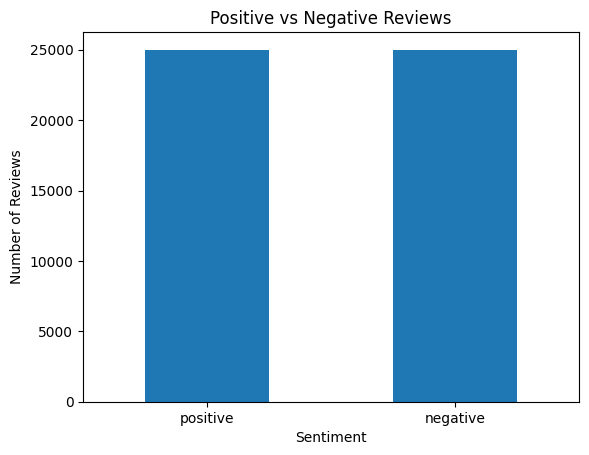

In [7]:
# Step 4: EDA — Class Distribution

import matplotlib.pyplot as plt

sentiment_counts = df["sentiment"].value_counts()

print(sentiment_counts)

sentiment_counts.plot(kind="bar")

plt.title("Positive vs Negative Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

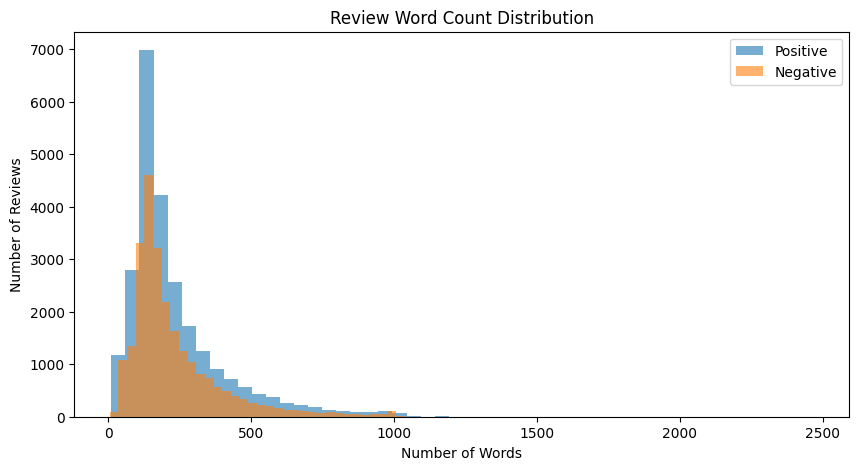

In [8]:
# Step 4: EDA — Word Count Histogram

df["word_count"] = df["review"].str.split().str.len()

plt.figure(figsize=(10, 5))

plt.hist(
    df[df["sentiment"] == "positive"]["word_count"],
    bins=50,
    alpha=0.6,
    label="Positive"
)

plt.hist(
    df[df["sentiment"] == "negative"]["word_count"],
    bins=50,
    alpha=0.6,
    label="Negative"
)

plt.title("Review Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.legend()
plt.show()

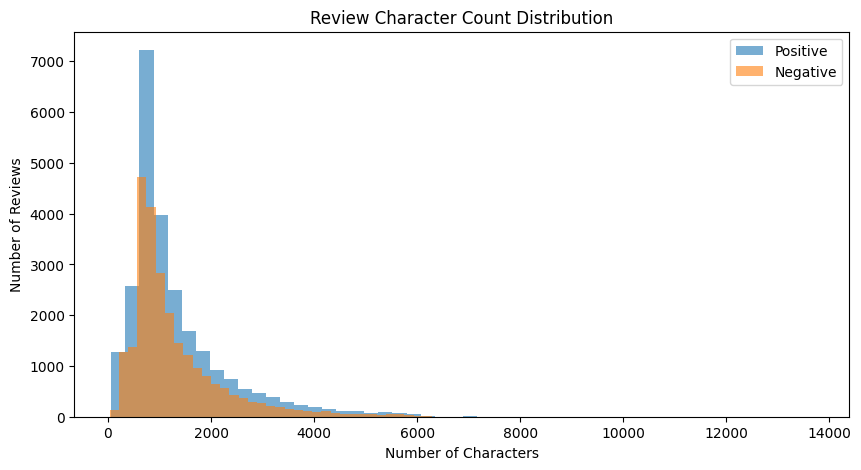

In [9]:
# Step 4: EDA — Character Count Histogram

df["char_count"] = df["review"].str.len()

plt.figure(figsize=(10, 5))

plt.hist(
    df[df["sentiment"] == "positive"]["char_count"],
    bins=50,
    alpha=0.6,
    label="Positive"
)

plt.hist(
    df[df["sentiment"] == "negative"]["char_count"],
    bins=50,
    alpha=0.6,
    label="Negative"
)

plt.title("Review Character Count Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Reviews")
plt.legend()
plt.show()

<Figure size 800x500 with 0 Axes>

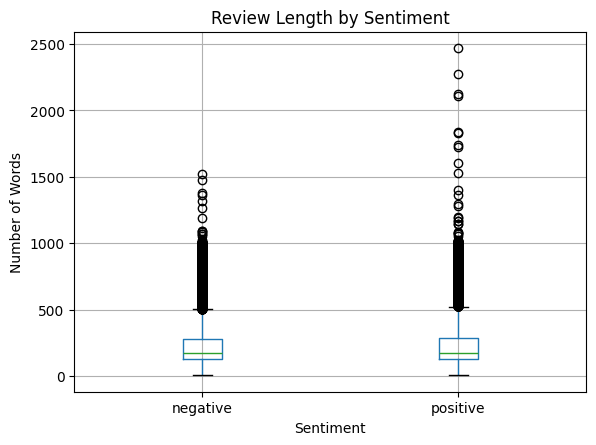

In [10]:
# Step 4: EDA — Review Length Box Plot

plt.figure(figsize=(8, 5))

df.boxplot(
    column="word_count",
    by="sentiment"
)

plt.title("Review Length by Sentiment")
plt.suptitle("")
plt.xlabel("Sentiment")
plt.ylabel("Number of Words")

plt.show()

In [11]:
# Step 5: EDA — Top 30 Most Frequent Words

from collections import Counter
import re

def get_top_words(texts, n=30):
    words = []

    for text in texts:
        text = re.sub(r"<.*?>", " ", text.lower())
        words.extend(re.findall(r"\b[a-zA-Z]+\b", text))

    # Remove common English stopwords
    words = [word for word in words if word not in stop_words]

    return Counter(words).most_common(n)


positive_reviews = df[df["sentiment"] == "positive"]["review"]
negative_reviews = df[df["sentiment"] == "negative"]["review"]

positive_top30 = get_top_words(positive_reviews)
negative_top30 = get_top_words(negative_reviews)

print("Top 30 Positive Words:")
print(positive_top30)

print("\nTop 30 Negative Words:")
print(negative_top30)

Top 30 Positive Words:
[('film', 42110), ('movie', 37854), ('not', 28302), ('one', 27320), ('like', 17714), ('good', 15025), ('great', 12964), ('story', 12934), ('time', 12752), ('well', 12729), ('see', 12276), ('also', 10793), ('really', 10739), ('would', 10595), ('even', 9617), ('no', 9235), ('first', 9230), ('much', 9201), ('people', 8719), ('love', 8692), ('best', 8510), ('get', 8285), ('life', 8137), ('way', 7865), ('many', 7627), ('films', 7601), ('made', 7351), ('think', 7208), ('two', 7161), ('characters', 7103)]

Top 30 Negative Words:
[('movie', 50116), ('film', 37595), ('not', 32446), ('one', 26283), ('like', 22458), ('no', 16057), ('even', 15254), ('good', 14728), ('bad', 14726), ('would', 14007), ('time', 12357), ('really', 12355), ('see', 10753), ('story', 10185), ('get', 10136), ('much', 10117), ('people', 9469), ('make', 9354), ('could', 9299), ('made', 8801), ('well', 8539), ('first', 8353), ('movies', 8313), ('plot', 8214), ('acting', 8087), ('way', 7780), ('character

In [12]:
# Step 5: EDA — Top 20 Bigrams by Class

from sklearn.feature_extraction.text import CountVectorizer

# Positive reviews
positive_vectorizer = CountVectorizer(
    stop_words=list(stop_words),
    ngram_range=(2, 2)
)

positive_matrix = positive_vectorizer.fit_transform(positive_reviews)

positive_bigram_counts = positive_matrix.sum(axis=0)
positive_bigrams = [
    (word, positive_bigram_counts[0, idx])
    for word, idx in positive_vectorizer.vocabulary_.items()
]

positive_bigrams = sorted(
    positive_bigrams,
    key=lambda x: x[1],
    reverse=True
)[:20]


# Negative reviews
negative_vectorizer = CountVectorizer(
    stop_words=list(stop_words),
    ngram_range=(2, 2)
)

negative_matrix = negative_vectorizer.fit_transform(negative_reviews)

negative_bigram_counts = negative_matrix.sum(axis=0)
negative_bigrams = [
    (word, negative_bigram_counts[0, idx])
    for word, idx in negative_vectorizer.vocabulary_.items()
]

negative_bigrams = sorted(
    negative_bigrams,
    key=lambda x: x[1],
    reverse=True
)[:20]


print("Top 20 Positive Bigrams:")
print(positive_bigrams)

print("\nTop 20 Negative Bigrams:")
print(negative_bigrams)

Top 20 Positive Bigrams:
[('br br', np.int64(49059)), ('one best', np.int64(1666)), ('br film', np.int64(1493)), ('br movie', np.int64(1106)), ('even though', np.int64(1099)), ('ever seen', np.int64(976)), ('first time', np.int64(960)), ('film br', np.int64(911)), ('movie br', np.int64(866)), ('film not', np.int64(858)), ('new york', np.int64(854)), ('movie not', np.int64(835)), ('special effects', np.int64(806)), ('br one', np.int64(794)), ('must see', np.int64(776)), ('see movie', np.int64(764)), ('real life', np.int64(761)), ('no one', np.int64(758)), ('years ago', np.int64(741)), ('10 10', np.int64(728))]

Top 20 Negative Bigrams:
[('br br', np.int64(52090)), ('ever seen', np.int64(1732)), ('special effects', np.int64(1442)), ('waste time', np.int64(1431)), ('not even', np.int64(1383)), ('br movie', np.int64(1365)), ('movie br', np.int64(1341)), ('looks like', np.int64(1232)), ('low budget', np.int64(1227)), ('movie not', np.int64(1160)), ('br film', np.int64(1108)), ('no one', np.

In [13]:
# Step 5: EDA — HTML Content Check

import re

html_tag_count = df["review"].str.count(r"<[^>]+>")

print("Reviews containing HTML tags:", (html_tag_count > 0).sum())
print("Reviews without HTML tags:", (html_tag_count == 0).sum())
print("Total HTML tags found:", html_tag_count.sum())

Reviews containing HTML tags: 29202
Reviews without HTML tags: 20798
Total HTML tags found: 201982


## Step 6: EDA Findings

### Class Balance
The dataset is balanced, with 25,000 positive reviews and 25,000 negative reviews. Therefore, accuracy is a valid evaluation metric.

### Vocabulary Differences
Positive reviews commonly contain words such as "good", "great", "love", and "best", while negative reviews contain words such as "bad", "plot", and "acting". These vocabulary differences can help distinguish sentiment.

### HTML Issue
The reviews contain HTML tags such as `<br />`. These tags are not useful for sentiment analysis and may introduce noise, so they should be removed during preprocessing.

### Motivation for Bigrams and Trigrams
Bigram analysis shows that multi-word phrases can provide useful sentiment information. Therefore, using bigrams and trigrams in TF-IDF vectorisation can help capture more context than individual words.

### Negation Challenge
Negation words such as "not", "no", and "never" can change the meaning of a sentence. For example, "good" and "not good" have different sentiment. Therefore, negation should be handled carefully during preprocessing.

In [14]:
# Step 7: Text Preprocessing Function

import re
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Stopwords
stop_words = set(stopwords.words("english"))

# Negation words ko keep karna hai
negation_words = {"not", "no", "never"}
stop_words = stop_words - negation_words

# Lemmatizer
lemmatizer = WordNetLemmatizer()

# Manual contraction expansion
contraction_map = {
    "don't": "do not",
    "doesn't": "does not",
    "didn't": "did not",
    "can't": "cannot",
    "couldn't": "could not",
    "wouldn't": "would not",
    "shouldn't": "should not",
    "won't": "will not",
    "isn't": "is not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "haven't": "have not",
    "hasn't": "has not",
    "hadn't": "had not",
    "i'm": "i am",
    "you're": "you are",
    "they're": "they are",
    "we're": "we are",
    "it's": "it is",
    "that's": "that is",
    "i've": "i have",
    "we've": "we have",
    "they've": "they have",
    "i'll": "i will",
    "you'll": "you will",
    "he'll": "he will",
    "she'll": "she will"
}

def expand_contractions(text):
    for contraction, expanded in contraction_map.items():
        text = re.sub(
            r"\b" + re.escape(contraction) + r"\b",
            expanded,
            text
        )
    return text


def clean_text(text):

    # 1. Remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text(" ")

    # 2. Lowercase
    text = text.lower()

    # 3. Expand contractions
    text = expand_contractions(text)

    # 4. Handle negation
    text = re.sub(
        r"\b(not|no|never)\s+([a-zA-Z]+)",
        r"\1_\2",
        text
    )

    # 5. Remove punctuation
    text = re.sub(r"[^a-zA-Z0-9_\s]", " ", text)

    # 6. Tokenization
    tokens = text.split()

    # 7. Remove stopwords, keeping negation words
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    # 8. Lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    # 9. Rejoin
    return " ".join(tokens)

In [15]:
# Step 7: Before and After Examples

examples = [
    df["review"].iloc[0],
    df["review"].iloc[1],
    df["review"].iloc[3],
    "I don't like this movie. It is not good.",
    "This film is excellent and I loved it."
]

for i, text in enumerate(examples, 1):

    print(f"\nExample {i}")

    print("BEFORE:")
    print(text[:300])

    print("\nAFTER:")
    print(clean_text(text))

    print("-" * 80)


Example 1
BEFORE:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru

AFTER:
one reviewer mentioned watching 1 oz episode hooked right exactly happened first thing struck oz brutality unflinching scene violence set right word go trust not_a show faint hearted timid show pull no_punches regard drug sex violence hardcore classic use word called oz nickname given oswald maximum security state penitentary focus mainly emerald city experimental section prison cell glass front face inwards privacy not_high agenda em city home many aryan muslim gangsta latino christian italian irish scuffle death stare dodgy dealing shady agreement never_far away would say main appeal show due fact go show would not_dare forget pretty picture painted mainstream a

In [16]:
# Step 8: Apply Preprocessing

from tqdm.auto import tqdm

tqdm.pandas()

df["cleaned_review"] = df["review"].progress_apply(clean_text)

print("Preprocessing completed successfully!")
print("Total reviews processed:", len(df))

# Show first 5 cleaned reviews
df[["review", "cleaned_review"]].head()

  0%|          | 0/50000 [00:00<?, ?it/s]

Preprocessing completed successfully!
Total reviews processed: 50000


,review,cleaned_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching 1 oz episode h...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...


In [17]:
# Step 9: Verify Negation Handling

test_sentences = [
    "This movie is not good.",
    "I don't like this movie.",
    "This film is never boring.",
    "There is no good acting here."
]

for text in test_sentences:
    cleaned = clean_text(text)

    print("Original :", text)
    print("Cleaned  :", cleaned)
    print("-" * 60)

# Check for negation tokens
print("\nNegation token check:")

negation_tokens = []

for text in df["cleaned_review"]:
    words = text.split()
    for word in words:
        if word.startswith(("not_", "no_", "never_")):
            negation_tokens.append(word)

print("Total negation tokens found:", len(negation_tokens))
print("Sample negation tokens:", negation_tokens[:20])

Original : This movie is not good.
Cleaned  : movie not_good
------------------------------------------------------------
Original : I don't like this movie.
Cleaned  : not_like movie
------------------------------------------------------------
Original : This film is never boring.
Cleaned  : film never_boring
------------------------------------------------------------
Original : There is no good acting here.
Cleaned  : no_good acting
------------------------------------------------------------

Negation token check:
Total negation tokens found: 150688
Sample negation tokens: ['not_a', 'no_punches', 'not_high', 'never_far', 'not_dare', 'not_mess', 'not_say', 'not_just', 'not_only', 'not_only', 'not_match', 'never_been', 'not_be', 'no_one', 'not_exactly', 'not_preachy', 'never_gets', 'not_really', 'not_for', 'not_still']


In [18]:
# Step 10: Train/Test Split

from sklearn.model_selection import train_test_split

# Features and labels
X = df["cleaned_review"]
y = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Check sizes
print("Training set size:", len(X_train))
print("Testing set size:", len(X_test))

# Verify class balance
print("\nTraining Set Class Balance:")
print(y_train.value_counts())

print("\nTesting Set Class Balance:")
print(y_test.value_counts())

Training set size: 40000
Testing set size: 10000

Training Set Class Balance:
sentiment
1    20000
0    20000
Name: count, dtype: int64

Testing Set Class Balance:
sentiment
0    5000
1    5000
Name: count, dtype: int64


In [19]:
# Step 11: TF-IDF Configuration 1 - Unigrams

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
import time

# Create TF-IDF vectorizer for unigrams
tfidf_uni = TfidfVectorizer(
    ngram_range=(1, 1),
    max_features=20000
)

# Fit on training data and transform training data
X_train_tfidf = tfidf_uni.fit_transform(X_train)

# Transform test data using the same fitted vectorizer
X_test_tfidf = tfidf_uni.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

# Train LinearSVC and record training time
start_time = time.time()

svm_uni = LinearSVC()
svm_uni.fit(X_train_tfidf, y_train)

training_time = time.time() - start_time

# Predict on test data
y_pred_uni = svm_uni.predict(X_test_tfidf)

# Calculate accuracy
accuracy_uni = accuracy_score(y_test, y_pred_uni)

print("\nLinearSVC - Unigram Results")
print("Test Accuracy:", accuracy_uni)
print("Training Time:", round(training_time, 2), "seconds")

Training TF-IDF shape: (40000, 20000)
Testing TF-IDF shape: (10000, 20000)

LinearSVC - Unigram Results
Test Accuracy: 0.9014
Training Time: 1.59 seconds


In [20]:
# Step 12: TF-IDF Configuration 2 - Unigrams + Sublinear TF

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
import time

# TF-IDF with sublinear term frequency
tfidf_sublinear = TfidfVectorizer(
    ngram_range=(1, 1),
    max_features=20000,
    sublinear_tf=True
)

# Fit only on training data
X_train_sublinear = tfidf_sublinear.fit_transform(X_train)

# Transform test data
X_test_sublinear = tfidf_sublinear.transform(X_test)

print("Training TF-IDF shape:", X_train_sublinear.shape)
print("Testing TF-IDF shape:", X_test_sublinear.shape)

# Train LinearSVC
start_time = time.time()

svm_sublinear = LinearSVC()
svm_sublinear.fit(X_train_sublinear, y_train)

training_time_sublinear = time.time() - start_time

# Predictions
y_pred_sublinear = svm_sublinear.predict(X_test_sublinear)

# Accuracy
accuracy_sublinear = accuracy_score(y_test, y_pred_sublinear)

print("\nLinearSVC - Unigram + Sublinear TF Results")
print("Test Accuracy:", accuracy_sublinear)
print("Training Time:", round(training_time_sublinear, 2), "seconds")

Training TF-IDF shape: (40000, 20000)
Testing TF-IDF shape: (10000, 20000)

LinearSVC - Unigram + Sublinear TF Results
Test Accuracy: 0.9006
Training Time: 1.23 seconds


In [21]:
# Step 13: TF-IDF Configuration 3 - Unigrams + Bigrams + Sublinear TF

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
import time

# Create TF-IDF vectorizer with unigrams + bigrams
tfidf_bigram = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=30000,
    sublinear_tf=True
)

# Fit only on training data
X_train_bigram = tfidf_bigram.fit_transform(X_train)

# Transform test data
X_test_bigram = tfidf_bigram.transform(X_test)

print("Training TF-IDF shape:", X_train_bigram.shape)
print("Testing TF-IDF shape:", X_test_bigram.shape)

# Train LinearSVC
start_time = time.time()

svm_bigram = LinearSVC()
svm_bigram.fit(X_train_bigram, y_train)

training_time_bigram = time.time() - start_time

# Predictions
y_pred_bigram = svm_bigram.predict(X_test_bigram)

# Accuracy
accuracy_bigram = accuracy_score(y_test, y_pred_bigram)

print("\nLinearSVC - Unigrams + Bigrams + Sublinear TF Results")
print("Test Accuracy:", accuracy_bigram)
print("Training Time:", round(training_time_bigram, 2), "seconds")

Training TF-IDF shape: (40000, 30000)
Testing TF-IDF shape: (10000, 30000)

LinearSVC - Unigrams + Bigrams + Sublinear TF Results
Test Accuracy: 0.9065
Training Time: 1.62 seconds


In [22]:
# Step 14: TF-IDF Configuration 4 - Unigrams + Bigrams + Trigrams + Sublinear TF

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
import time

# Create TF-IDF vectorizer with unigrams + bigrams + trigrams
tfidf_trigram = TfidfVectorizer(
    ngram_range=(1, 3),
    max_features=50000,
    sublinear_tf=True
)

# Fit only on training data
X_train_trigram = tfidf_trigram.fit_transform(X_train)

# Transform test data
X_test_trigram = tfidf_trigram.transform(X_test)

print("Training TF-IDF shape:", X_train_trigram.shape)
print("Testing TF-IDF shape:", X_test_trigram.shape)

# Train LinearSVC
start_time = time.time()

svm_trigram = LinearSVC(C=1.0)
svm_trigram.fit(X_train_trigram, y_train)

training_time_trigram = time.time() - start_time

# Predictions
y_pred_trigram = svm_trigram.predict(X_test_trigram)

# Accuracy
accuracy_trigram = accuracy_score(y_test, y_pred_trigram)

print("\nLinearSVC - Trigrams + Sublinear TF Results")
print("Test Accuracy:", accuracy_trigram)
print("Training Time:", round(training_time_trigram, 2), "seconds")

Training TF-IDF shape: (40000, 50000)
Testing TF-IDF shape: (10000, 50000)

LinearSVC - Trigrams + Sublinear TF Results
Test Accuracy: 0.9123
Training Time: 0.82 seconds


In [23]:
# Step 15: Algorithm Comparison
# Best TF-IDF configuration: Unigrams + Bigrams + Trigrams + Sublinear TF

from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
import time

# Store results
results = []

# -----------------------------------
# 1. LinearSVC
# -----------------------------------

start_time = time.time()

model_svc = LinearSVC(C=1.0)
model_svc.fit(X_train_trigram, y_train)

svc_time = time.time() - start_time

y_pred_svc = model_svc.predict(X_test_trigram)
svc_accuracy = accuracy_score(y_test, y_pred_svc)

results.append(["LinearSVC", svc_accuracy, svc_time])

print("LinearSVC")
print("Accuracy:", svc_accuracy)
print("Training Time:", round(svc_time, 2), "seconds")


# -----------------------------------
# 2. Logistic Regression
# -----------------------------------

start_time = time.time()

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_trigram, y_train)

lr_time = time.time() - start_time

y_pred_lr = model_lr.predict(X_test_trigram)
lr_accuracy = accuracy_score(y_test, y_pred_lr)

results.append(["Logistic Regression", lr_accuracy, lr_time])

print("\nLogistic Regression")
print("Accuracy:", lr_accuracy)
print("Training Time:", round(lr_time, 2), "seconds")


# -----------------------------------
# 3. Multinomial Naive Bayes
# -----------------------------------

start_time = time.time()

model_nb = MultinomialNB()
model_nb.fit(X_train_trigram, y_train)

nb_time = time.time() - start_time

y_pred_nb = model_nb.predict(X_test_trigram)
nb_accuracy = accuracy_score(y_test, y_pred_nb)

results.append(["Multinomial Naive Bayes", nb_accuracy, nb_time])

print("\nMultinomial Naive Bayes")
print("Accuracy:", nb_accuracy)
print("Training Time:", round(nb_time, 2), "seconds")


# -----------------------------------
# Final Comparison
# -----------------------------------

print("\n" + "=" * 60)
print("ALGORITHM COMPARISON")
print("=" * 60)

for model, accuracy, train_time in results:
    print(
        f"{model}: "
        f"Accuracy = {accuracy:.4f} "
        f"({accuracy*100:.2f}%), "
        f"Training Time = {train_time:.2f} seconds"
    )

LinearSVC
Accuracy: 0.9123
Training Time: 0.82 seconds

Logistic Regression
Accuracy: 0.9103
Training Time: 2.53 seconds

Multinomial Naive Bayes
Accuracy: 0.8888
Training Time: 0.12 seconds

ALGORITHM COMPARISON
LinearSVC: Accuracy = 0.9123 (91.23%), Training Time = 0.82 seconds
Logistic Regression: Accuracy = 0.9103 (91.03%), Training Time = 2.53 seconds
Multinomial Naive Bayes: Accuracy = 0.8888 (88.88%), Training Time = 0.12 seconds


In [24]:
# Step 16: Hyperparameter Tuning for LinearSVC

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

# Create Pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 3),
        max_features=50000,
        sublinear_tf=True
    )),
    ('clf', LinearSVC())
])

# Values of C to test
param_grid = {
    'clf__C': [0.01, 0.1, 1.0, 10.0]
}

# GridSearchCV
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Run tuning
grid_search.fit(X_train, y_train)

# Best result
print("\nBest C:", grid_search.best_params_['clf__C'])
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits

Best C: 1.0
Best Cross-Validation Accuracy: 0.9038250067546124


In [25]:
# Step 17: Final Model Pipeline + 5-Fold Cross-Validation

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

# Final Pipeline
final_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 3),
        max_features=50000,
        sublinear_tf=True
    )),
    ('clf', LinearSVC(C=1.0))
])

# Train final model
final_pipeline.fit(X_train, y_train)

# Test prediction
y_pred_final = final_pipeline.predict(X_test)

# Test accuracy
test_accuracy = accuracy_score(y_test, y_pred_final)

print("Final Model Test Accuracy:", test_accuracy)
print("Final Model Test Accuracy (%):", round(test_accuracy * 100, 2))

# 5-Fold Cross-Validation
cv_scores = cross_val_score(
    final_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print("\n5-Fold Cross-Validation Scores:")
print(cv_scores)

print("\nMean CV Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

print(
    "CV Accuracy: {:.2f}% ± {:.2f}%".format(
        cv_scores.mean() * 100,
        cv_scores.std() * 100
    )
)

Final Model Test Accuracy: 0.9123
Final Model Test Accuracy (%): 91.23

5-Fold Cross-Validation Scores:
[0.907375 0.902625 0.904125 0.903375 0.903875]

Mean CV Accuracy: 0.9042749999999999
Standard Deviation: 0.0016324827717314621
CV Accuracy: 90.43% ± 0.16%


In [26]:
# Step 18: Get missing accuracy values

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

configs = [
    ("Unigram", (1, 1), 20000, False),
    ("Unigram + Sublinear TF", (1, 1), 20000, True),
    ("Unigram + Bigram + Sublinear TF", (1, 2), 30000, True)
]

missing_results = {}

for name, ngram_range, max_features, sublinear in configs:

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    vectorizer = TfidfVectorizer(
        ngram_range=ngram_range,
        max_features=max_features,
        sublinear_tf=sublinear
    )

    X_train_config = vectorizer.fit_transform(X_train)
    X_test_config = vectorizer.transform(X_test)

    # Logistic Regression
    lr_model = LogisticRegression(max_iter=1000)
    lr_model.fit(X_train_config, y_train)

    lr_pred = lr_model.predict(X_test_config)
    lr_accuracy = accuracy_score(y_test, lr_pred)

    print("Logistic Regression Accuracy:", round(lr_accuracy, 4))

    # Multinomial Naive Bayes
    nb_model = MultinomialNB(alpha=1.0)
    nb_model.fit(X_train_config, y_train)

    nb_pred = nb_model.predict(X_test_config)
    nb_accuracy = accuracy_score(y_test, nb_pred)

    print("Multinomial Naive Bayes Accuracy:", round(nb_accuracy, 4))

    missing_results[name] = {
        "Logistic Regression": lr_accuracy,
        "Multinomial Naive Bayes": nb_accuracy
    }

print("\n" + "=" * 60)
print("MISSING RESULTS")
print("=" * 60)

for config, results in missing_results.items():
    print(
        config,
        "→ Logistic Regression:",
        round(results["Logistic Regression"], 4),
        "| Naive Bayes:",
        round(results["Multinomial Naive Bayes"], 4)
    )


Unigram
Logistic Regression Accuracy: 0.9024
Multinomial Naive Bayes Accuracy: 0.8683

Unigram + Sublinear TF
Logistic Regression Accuracy: 0.9059
Multinomial Naive Bayes Accuracy: 0.8706

Unigram + Bigram + Sublinear TF
Logistic Regression Accuracy: 0.9092
Multinomial Naive Bayes Accuracy: 0.8842

MISSING RESULTS
Unigram → Logistic Regression: 0.9024 | Naive Bayes: 0.8683
Unigram + Sublinear TF → Logistic Regression: 0.9059 | Naive Bayes: 0.8706
Unigram + Bigram + Sublinear TF → Logistic Regression: 0.9092 | Naive Bayes: 0.8842


Accuracy Comparison:


,LinearSVC,Logistic Regression,Multinomial Naive Bayes
Unigram,0.9014,0.9024,0.8683
Unigram + Sublinear TF,0.9006,0.9059,0.8706
Unigram + Bigram + Sublinear TF,0.9065,0.9092,0.8842
Trigram + Sublinear TF,0.9123,0.9103,0.8888


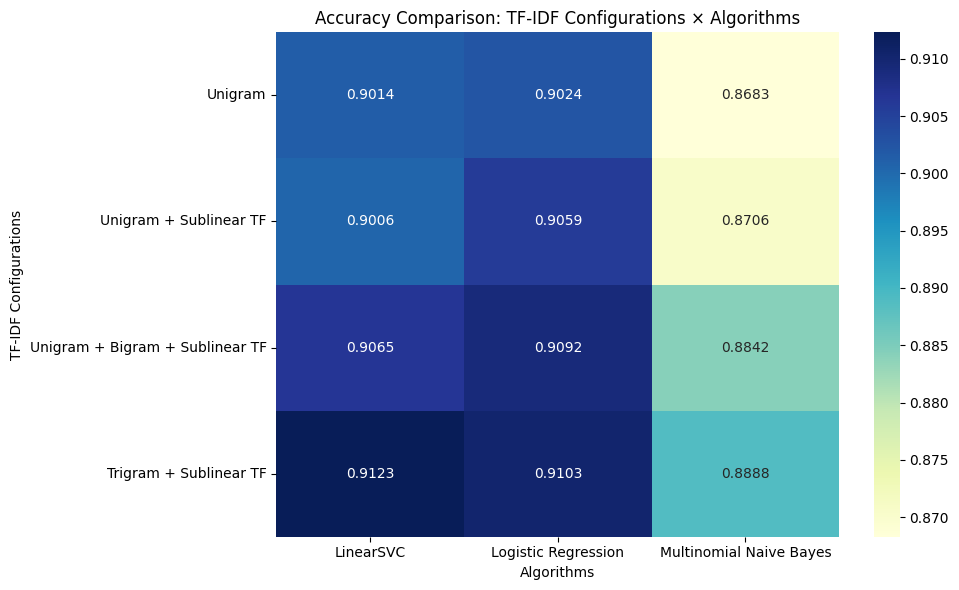

In [27]:
# Step 18: Full Comparison Heatmap

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# All 12 actual accuracy results
heatmap_data = {
    "LinearSVC": [
        0.9014,
        0.9006,
        0.9065,
        0.9123
    ],

    "Logistic Regression": [
        0.9024,
        0.9059,
        0.9092,
        0.9103
    ],

    "Multinomial Naive Bayes": [
        0.8683,
        0.8706,
        0.8842,
        0.8888
    ]
}

configurations = [
    "Unigram",
    "Unigram + Sublinear TF",
    "Unigram + Bigram + Sublinear TF",
    "Trigram + Sublinear TF"
]

# Create comparison table
heatmap_df = pd.DataFrame(
    heatmap_data,
    index=configurations
)

print("Accuracy Comparison:")
display(heatmap_df)

# Create heatmap
plt.figure(figsize=(10, 6))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".4f",
    cmap="YlGnBu"
)

plt.title("Accuracy Comparison: TF-IDF Configurations × Algorithms")
plt.xlabel("Algorithms")
plt.ylabel("TF-IDF Configurations")

plt.tight_layout()
plt.show()

TOP 20 POSITIVE-PREDICTING WORDS
excellent                 3.4668
great                     3.4050
perfect                   2.6981
amazing                   2.5724
hilarious                 2.5222
must see                  2.5012
enjoyable                 2.4276
wonderful                 2.2898
fun                       2.2612
refreshing                2.2209
enjoyed                   2.2204
well worth                2.2185
one better                2.1732
perfectly                 2.1657
one best                  2.1619
loved                     2.1452
today                     2.1393
best                      2.1346
brilliant                 2.1300
10 10                     2.1120

TOP 20 NEGATIVE-PREDICTING WORDS
worst                     -4.6367
awful                     -4.1636
bad                       -3.7154
boring                    -3.6044
waste                     -3.4085
fails                     -3.3992
disappointing             -3.0806
disappointment            -2.8592
n

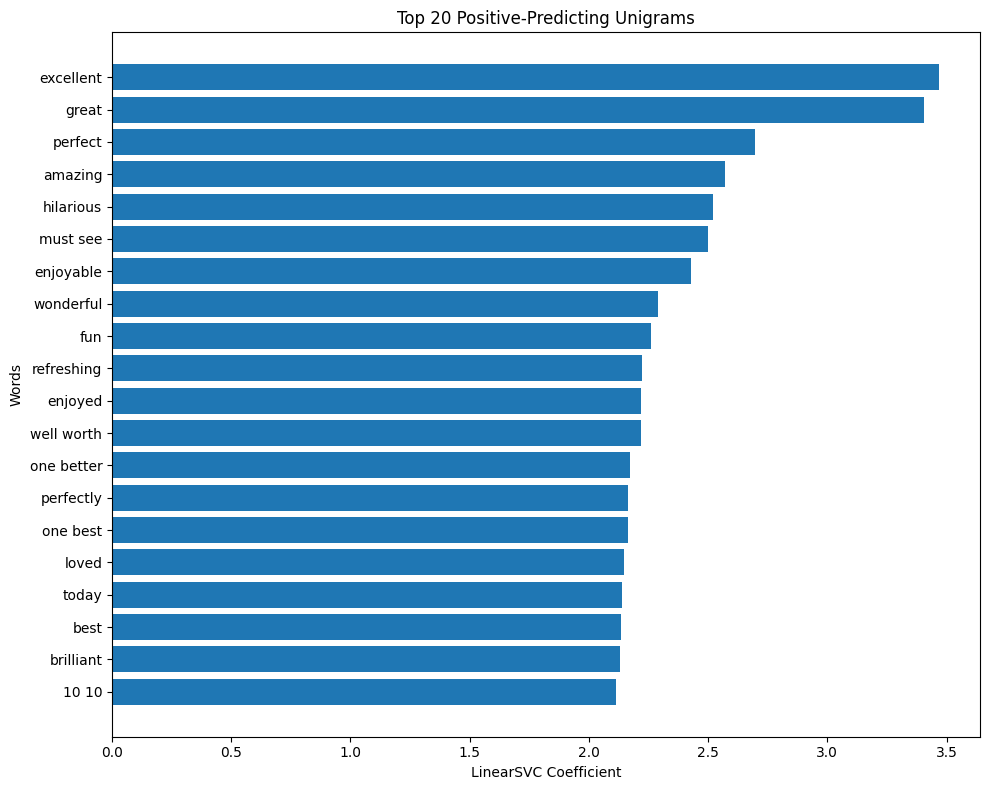

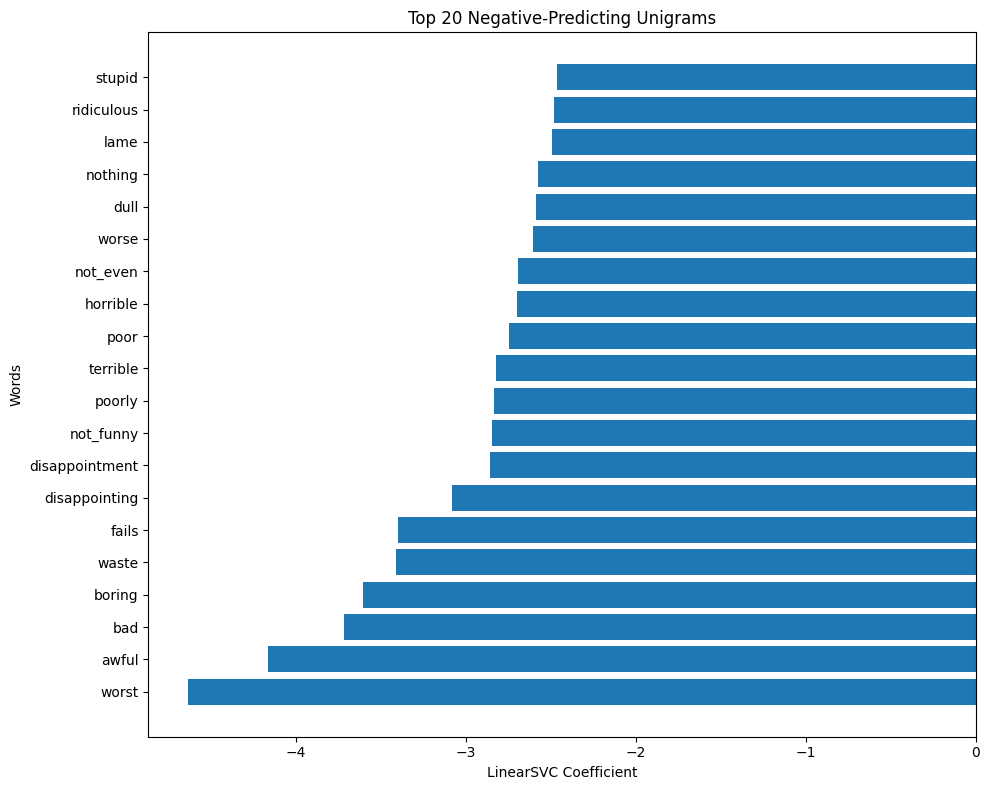

In [28]:
# Step 19: Most Informative Words - Unigrams

import numpy as np
import matplotlib.pyplot as plt

# Get the trained TF-IDF vectorizer and LinearSVC model
vectorizer = final_pipeline.named_steps["tfidf"]
model = final_pipeline.named_steps["clf"]

# Get feature names
feature_names = np.array(vectorizer.get_feature_names_out())

# Get LinearSVC coefficients
coefficients = model.coef_[0]

# Top 20 positive words
top_positive_indices = np.argsort(coefficients)[-20:][::-1]
top_positive_words = feature_names[top_positive_indices]
top_positive_scores = coefficients[top_positive_indices]

# Top 20 negative words
top_negative_indices = np.argsort(coefficients)[:20]
top_negative_words = feature_names[top_negative_indices]
top_negative_scores = coefficients[top_negative_indices]

# Print results
print("=" * 60)
print("TOP 20 POSITIVE-PREDICTING WORDS")
print("=" * 60)

for word, score in zip(top_positive_words, top_positive_scores):
    print(f"{word:25s} {score:.4f}")

print("\n" + "=" * 60)
print("TOP 20 NEGATIVE-PREDICTING WORDS")
print("=" * 60)

for word, score in zip(top_negative_words, top_negative_scores):
    print(f"{word:25s} {score:.4f}")


# -----------------------------
# Positive words chart
# -----------------------------
plt.figure(figsize=(10, 8))

plt.barh(
    top_positive_words[::-1],
    top_positive_scores[::-1]
)

plt.xlabel("LinearSVC Coefficient")
plt.ylabel("Words")
plt.title("Top 20 Positive-Predicting Unigrams")
plt.tight_layout()
plt.show()


# -----------------------------
# Negative words chart
# -----------------------------
plt.figure(figsize=(10, 8))

plt.barh(
    top_negative_words,
    top_negative_scores
)

plt.xlabel("LinearSVC Coefficient")
plt.ylabel("Words")
plt.title("Top 20 Negative-Predicting Unigrams")
plt.tight_layout()
plt.show()

TOP 20 POSITIVE-PREDICTING BIGRAMS
must see                       2.5012
well worth                     2.2185
one better                     2.1732
one best                       2.1619
10 10                          2.1120
cannot wait                    1.8004
definitely worth               1.7774
loved movie                    1.6740
even better                    1.6573
not_a bad                      1.6177
bit long                       1.5086
highly recommended             1.4979
surprisingly good              1.4738
highly recommend               1.4694
well done                      1.4558
may not_be                     1.4444
really good                    1.4102
none less                      1.3837
life movie                     1.3235
one man                        1.2980

TOP 20 NEGATIVE-PREDICTING BIGRAMS
not_a good                     -2.3710
one worst                      -1.8889
waste time                     -1.7154
bad film                       -1.6864
fast forward 

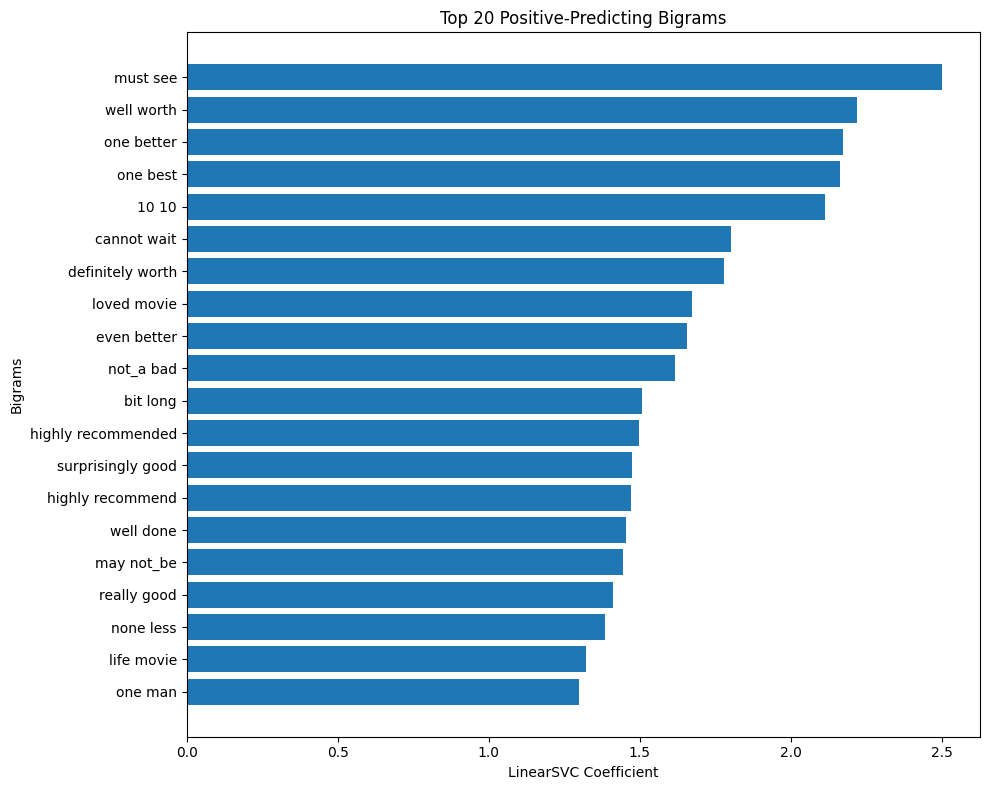

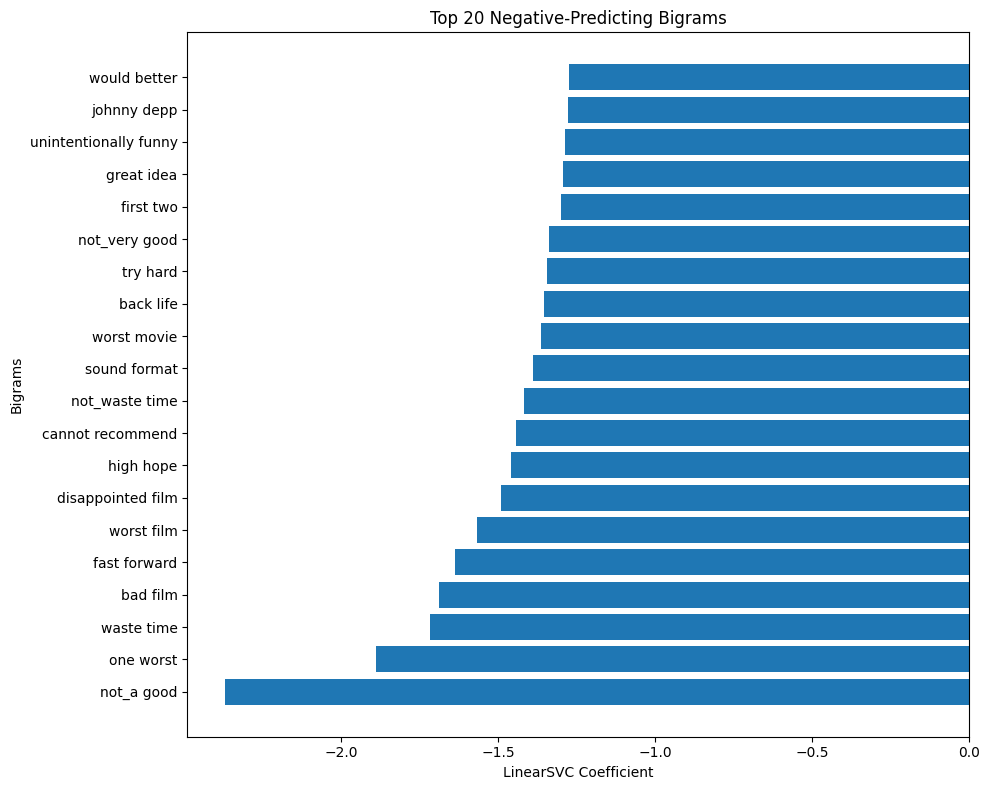


NEGATION-RELATED BIGRAMS
not_a bad                      1.6177
may not_be                     1.4444
not_be disappointed            1.2446
not_take seriously             1.2026
people not_like                1.1286
not_even know                  1.1237
not_very scary                 0.9235
not_the greatest               0.8300
not_even go                    0.8255
not_feel like                  0.8143
not_a fan                      0.8133
not_care one                   0.8118
not_your typical               0.8055
never_get tired                0.7747
acting not_that                0.7736
film not_for                   0.7708
could not_help                 0.7370
certainly not_a                0.7323
would not_say                  0.7127
like no_other                  0.7075


In [29]:
# Step 20: Most Informative Bigrams & Negation

import numpy as np
import matplotlib.pyplot as plt

# TF-IDF features from the final model
feature_names = np.array(
    final_pipeline.named_steps["tfidf"].get_feature_names_out()
)

# LinearSVC coefficients
coefficients = final_pipeline.named_steps["clf"].coef_[0]

# Keep only BIGRAM features
bigram_indices = np.array([
    i for i, feature in enumerate(feature_names)
    if len(feature.split()) == 2
])

bigram_features = feature_names[bigram_indices]
bigram_coefficients = coefficients[bigram_indices]

# Top 20 positive bigrams
positive_order = np.argsort(bigram_coefficients)[-20:][::-1]

top_positive_bigrams = bigram_features[positive_order]
top_positive_scores = bigram_coefficients[positive_order]

# Top 20 negative bigrams
negative_order = np.argsort(bigram_coefficients)[:20]

top_negative_bigrams = bigram_features[negative_order]
top_negative_scores = bigram_coefficients[negative_order]


# Print positive bigrams
print("=" * 60)
print("TOP 20 POSITIVE-PREDICTING BIGRAMS")
print("=" * 60)

for phrase, score in zip(top_positive_bigrams, top_positive_scores):
    print(f"{phrase:30s} {score:.4f}")


# Print negative bigrams
print("\n" + "=" * 60)
print("TOP 20 NEGATIVE-PREDICTING BIGRAMS")
print("=" * 60)

for phrase, score in zip(top_negative_bigrams, top_negative_scores):
    print(f"{phrase:30s} {score:.4f}")


# Positive bigram chart
plt.figure(figsize=(10, 8))

plt.barh(
    top_positive_bigrams[::-1],
    top_positive_scores[::-1]
)

plt.xlabel("LinearSVC Coefficient")
plt.ylabel("Bigrams")
plt.title("Top 20 Positive-Predicting Bigrams")
plt.tight_layout()
plt.show()


# Negative bigram chart
plt.figure(figsize=(10, 8))

plt.barh(
    top_negative_bigrams,
    top_negative_scores
)

plt.xlabel("LinearSVC Coefficient")
plt.ylabel("Bigrams")
plt.title("Top 20 Negative-Predicting Bigrams")
plt.tight_layout()
plt.show()


# Find negation-related bigrams
negation_terms = ["not_", "no_", "never_", "neither_", "hardly_"]

negation_bigrams = [
    (feature, score)
    for feature, score in zip(bigram_features, bigram_coefficients)
    if any(term in feature for term in negation_terms)
]

print("\n" + "=" * 60)
print("NEGATION-RELATED BIGRAMS")
print("=" * 60)

for phrase, score in sorted(negation_bigrams, key=lambda x: x[1], reverse=True)[:20]:
    print(f"{phrase:30s} {score:.4f}")

Confusion Matrix:
[[4528  472]
 [ 405 4595]]


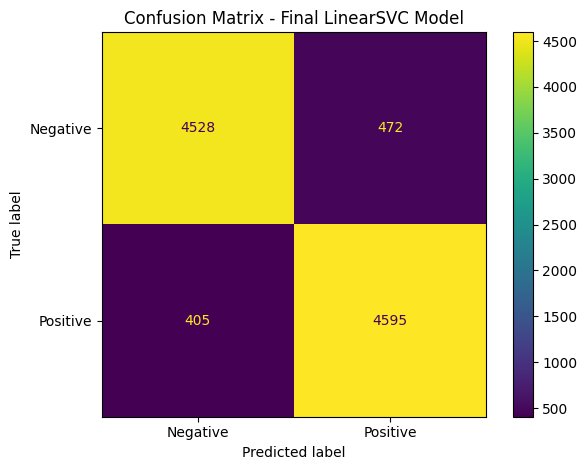


CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.92      0.91      0.91      5000
    Positive       0.91      0.92      0.91      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [30]:
# Step 21: Confusion Matrix & Classification Report

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Predictions from the final/best model
y_pred_final = final_pipeline.predict(X_test)

# -----------------------------
# 1. Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred_final)

print("Confusion Matrix:")
print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix - Final LinearSVC Model")
plt.tight_layout()
plt.show()


# -----------------------------
# 2. Classification Report
# -----------------------------
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=["Negative", "Positive"]
    )
)

In [31]:
# Step 22: Error Analysis

import numpy as np
import pandas as pd

# Final model predictions
y_pred = final_pipeline.predict(X_test)

# Prediction confidence / decision scores
decision_scores = final_pipeline.decision_function(X_test)

# Create error-analysis dataframe
error_df = pd.DataFrame({
    "Review": X_test,
    "Actual": y_test,
    "Predicted": y_pred,
    "Decision_Score": decision_scores
})

# Keep only incorrectly classified reviews
errors = error_df[error_df["Actual"] != error_df["Predicted"]].copy()

print("=" * 70)
print("ERROR ANALYSIS")
print("=" * 70)

print("Total test reviews:", len(error_df))
print("Incorrect predictions:", len(errors))
print(
    "Error Rate:",
    round(len(errors) / len(error_df) * 100, 2),
    "%"
)

print("\nFirst 10 Misclassified Reviews:")
display(errors.head(10))

ERROR ANALYSIS
Total test reviews: 10000
Incorrect predictions: 877
Error Rate: 8.77 %

First 10 Misclassified Reviews:


,Review,Actual,Predicted,Decision_Score
18870,yes mtv really way market daria started clever...,0,1,0.177949
40714,little quentin seems mastered art cake eating ...,0,1,1.047383
31882,film listed made 1980 not_the film available s...,0,1,0.425953
7266,farrah fawcett give award nominated performanc...,1,0,-0.104736
4142,movie gung ho story carlson makin island raide...,0,1,0.119245
11840,known brad linaweaver florida state u early 70...,0,1,1.034891
48388,order enjoy fur imaginary portrait diane arbus...,0,1,0.159526
20169,quite fan novelist screenwriter michael chabon...,0,1,0.026361
46536,cannot believe comment show show genius sure n...,1,0,-0.348892
39806,1 seen branaghs hamlet branagh old speaks freq...,1,0,-0.256148


In [32]:
# Confidently Wrong Predictions

# Wrong predictions
wrong_predictions = error_df[
    error_df["Actual"] != error_df["Predicted"]
].copy()

# Confidence = absolute decision score
wrong_predictions["Confidence"] = (
    wrong_predictions["Decision_Score"].abs()
)

# Sort from most confident to least confident
confidently_wrong = wrong_predictions.sort_values(
    by="Confidence",
    ascending=False
)

print("=" * 70)
print("TOP CONFIDENTLY WRONG PREDICTIONS")
print("=" * 70)

display(
    confidently_wrong[
        ["Review", "Actual", "Predicted",
         "Decision_Score", "Confidence"]
    ].head(10)
)

TOP CONFIDENTLY WRONG PREDICTIONS


,Review,Actual,Predicted,Decision_Score,Confidence
41703,sleek sexy movie must see upon multiple viewin...,0,1,2.440075,2.440075
42989,major payne film major make life living hell s...,0,1,1.828306,1.828306
186,not_read anne rice novel movie based know mayb...,1,0,-1.816339,1.816339
22839,would not_say bad movie fact pretty typical ty...,1,0,-1.622799,1.622799
12210,not_citizen kane deliver cleavage lot badly ac...,1,0,-1.582344,1.582344
40304,okay first got movie christmas present free fi...,1,0,-1.552886,1.552886
37447,loved movie first came 12 year old forgotten f...,0,1,1.528489,1.528489
17140,saw winnie heffalump couple day ago nice story...,0,1,1.509816,1.509816
14916,great movie especially music etta james last s...,0,1,1.466168,1.466168
23800,pretty simplistic romance girl find boy girl l...,0,1,1.464542,1.464542


In [33]:
# Short vs Long Review Accuracy

# Count words in each review
review_lengths = X_test.apply(lambda x: len(str(x).split()))

# Short reviews: less than 50 words
short_mask = review_lengths < 50

# Long reviews: more than 200 words
long_mask = review_lengths > 200

# Accuracy for short reviews
short_accuracy = (
    y_pred_final[short_mask] == np.array(y_test)[short_mask]
).mean()

# Accuracy for long reviews
long_accuracy = (
    y_pred_final[long_mask] == np.array(y_test)[long_mask]
).mean()

print("=" * 70)
print("SHORT VS LONG REVIEW ACCURACY")
print("=" * 70)

print("Short reviews (< 50 words):")
print("Number of reviews:", short_mask.sum())
print("Accuracy:", round(short_accuracy * 100, 2), "%")

print("\nLong reviews (> 200 words):")
print("Number of reviews:", long_mask.sum())
print("Accuracy:", round(long_accuracy * 100, 2), "%")

SHORT VS LONG REVIEW ACCURACY
Short reviews (< 50 words):
Number of reviews: 1155
Accuracy: 92.21 %

Long reviews (> 200 words):
Number of reviews: 1421
Accuracy: 91.48 %


## Step 23: Conclusions

### Final Model
The best-performing model was LinearSVC with TF-IDF trigrams and sublinear TF scaling.

The final test accuracy was **91.23%**, while 5-fold cross-validation achieved a mean accuracy of **90.43% ± 0.16%**.

### TF-IDF and N-gram Findings
Using unigrams, bigrams, and finally trigrams improved the model's ability to capture sentiment-related phrases and local context.

The trigram configuration achieved the best performance among the tested TF-IDF configurations.

### Sublinear TF
Sublinear TF scaling reduced the influence of repeated words within a review and improved the representation of term frequency.

### Negation Handling
Negation handling created features such as `not_good` and `not_bad`, allowing the model to distinguish sentiment more effectively when negation was present.

### Error Analysis
The model correctly classified most reviews but made **877 errors out of 10,000 test reviews**, giving an error rate of **8.77%**.

Confidently wrong predictions showed that the model can still struggle with negation, sarcasm or irony, mixed sentiment, and genre-specific vocabulary.

Short reviews achieved **92.21% accuracy**, while long reviews achieved **91.48% accuracy** in our test set.

### Limitations
The TF-IDF + LinearSVC approach mainly relies on word and n-gram patterns. It has limited ability to understand long-range context, sarcasm, irony, and deeper meaning.

### Future Improvement
Deep learning and transformer-based models such as **BERT** could better capture context, word relationships, negation, and complex sentiment patterns.

### Overall Conclusion
The project demonstrates that classical NLP with TF-IDF and LinearSVC can achieve strong performance on movie-review sentiment classification, with a final test accuracy of **91.23%**.